<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/regressao_logistica_exercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios de Regressão Logística e Classificação Binária

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$

Resposta: $$2x1.2 + 0.3x0.1 + 0.5 = 2.93$$


### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$

Resposta:
$$
0.94 = \frac{1}{1 + e^{-2.93}}
$$

### c) Classificação final

- Se $\hat{y} > 0.5$ → Classe 1  
- Caso contrário → Classe 0  

Resposta: Classe 1

## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$? O peso, o quão importante é cada variével na previsão final
2. Qual o papel do $b$? Viés, a flexibilidade de um modelo. Pensando em relação aos dados de treino, quando um modelo é mais flexível em relação aos dados
3. Por que usamos a função sigmoide? Limiar de decisão, ele estima a probabilidade de uma dada amostra de entrada pertencer à Classe Positiva, se o valor calculado for maior que 0.5, ele tem mais chances de pertencer a Classe Positiva

Dica:

- $w$ → importância de cada variável  
- $b$ → ajuste da linha  
- Sigmoide → transforma em probabilidade  

# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

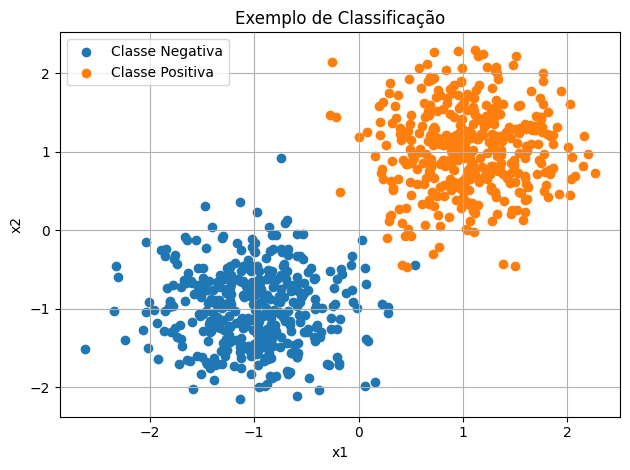

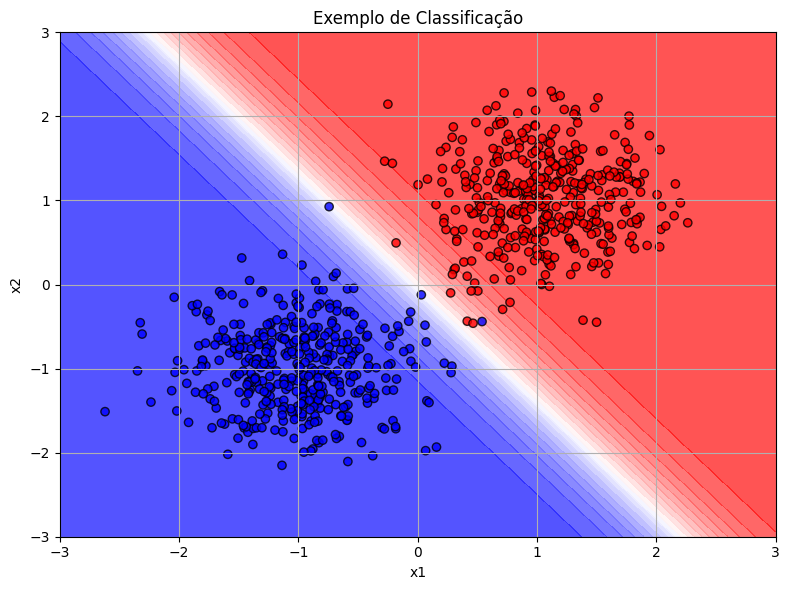

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

N = 400

# Classe 0
x0 = np.random.randn(N, 2) * 0.5 - 1
y0 = np.zeros(N)

# Classe 1
x1 = np.random.randn(N, 2) * 0.5 + 1
y1 = np.ones(N)

# Juntar dados
X = np.vstack([x0, x1])
y = np.hstack([y0, y1])

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Predição
y_pred = modelo.predict(X_test)

# Plot dos dados
plt.scatter(x0[:, 0], x0[:, 1], label="Classe Negativa")
plt.scatter(x1[:, 0], x1[:, 1], label="Classe Positiva")

plt.title("Exemplo de Classificação")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Fronteira de decisão
xx, yy = np.meshgrid(np.linspace(-3, 3, 200),
                     np.linspace(-3, 3, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = modelo.predict_proba(grid)[:,1].reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Exemplo de Classificação")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.tight_layout()
plt.show()

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

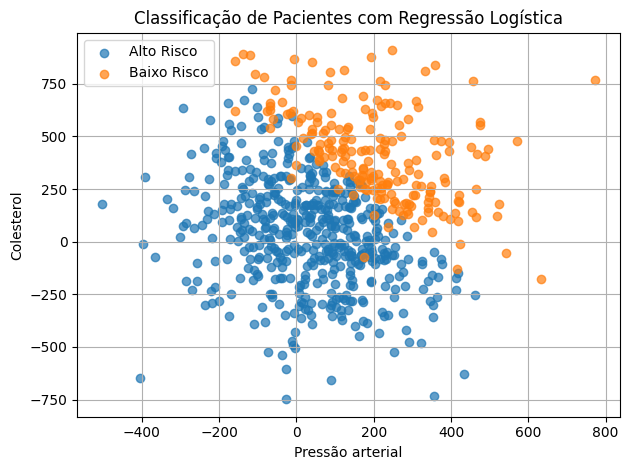

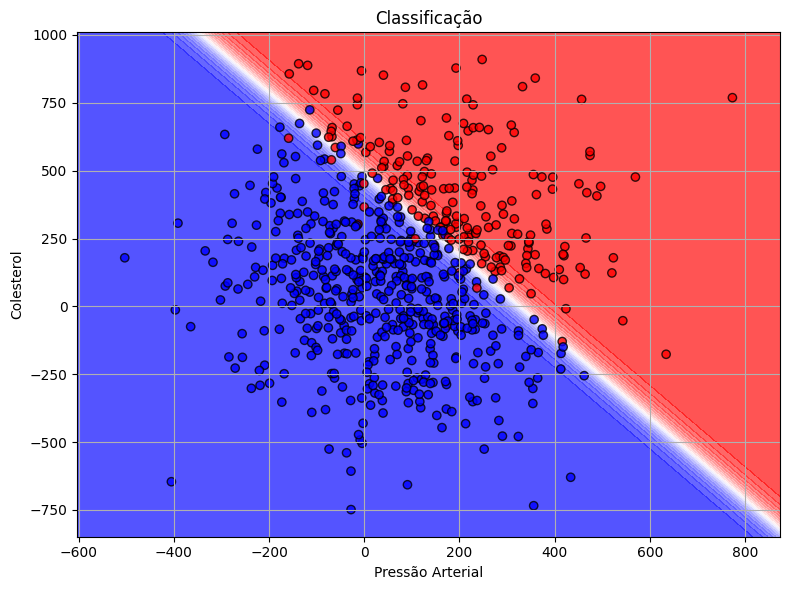

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Simular pacientes
np.random.seed(42)
N = 700


# P = pressão, C = colesterol
P = np.random.normal(80, 180, N)
C = np.random.normal(120, 300, N)

# 2. Calcular p

z = 0.03*P+0.02*C-10

p = 1/(1 + np.exp(-z))

# 3. Criar classes
y = np.random.binomial(1, p)
X = np.column_stack([P, C])

# 4. Treinar modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

classe_0 = X[y == 0]
classe_1 = X[y == 1]

plt.scatter(classe_0[:, 0], classe_0[:, 1], label="Alto Risco", alpha=0.7)
plt.scatter(classe_1[:, 0], classe_1[:, 1], label="Baixo Risco", alpha=0.7)

plt.title("Classificação de Pacientes com Regressão Logística")
plt.xlabel("Pressão arterial")
plt.ylabel("Colesterol")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

x_min, x_max = X[:, 0].min() - 100, X[:, 0].max() + 100
y_min, y_max = X[:, 1].min() - 100, X[:, 1].max() + 100

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = modelo.predict_proba(grid)[:,1].reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, alpha=0.7, cmap="bwr")
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Classificação")
plt.xlabel("Pressão Arterial")
plt.ylabel("Colesterol")
plt.grid(True)
plt.tight_layout()
plt.show()